# Mini-Project 2: Solar Micro-Grid Dispatch Planner

**The scenario.** A rural health centre in Kasese runs a micro-grid. Each
day the energy drawn from solar panels (`x`) and batteries (`y`) must meet
two demand constraints:

$$3x + 2y = D_1 \quad\text{(daytime load, kWh)}$$
$$4x + \phantom{2}y = D_2 \quad\text{(critical-equipment load, kWh)}$$

**What has to be settled.** Whether the system is worth solving at all, how
the energy splits across 30 days, what to do about days with no physical
answer, which source is the more erratic, and what it costs.

**How this build is arranged.** `src/microgrid.py`. The repair rule for
infeasible days is a **pluggable strategy object** rather than a method
baked into the grid, so the two obvious choices can be compared on the same
data instead of one being assumed.

In [1]:
import sys
import timeit
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.charts import DATA, SERIES_COLOURS, store, use_house_style
from src.microgrid import (
    BoundedLeastSquares, ClipToZero, DemandSource, EnergyTariff, HybridMicroGrid,
    MicroGrid, perturbation_study)

use_house_style()
SEED = 1234
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.3f}".format)

grid = MicroGrid()
print(repr(grid))

MicroGrid(size=2, det=-5, cond=5.828, repair=bounded-lsq)


## Task 1: is the system well posed?

Two numbers decide whether solving is worthwhile.

* **The determinant**, $\det A = 3\times1 - 2\times4 = -5$, is non-zero, so
  the two loads are linearly independent and every demand pair has exactly
  one solar/battery mix behind it. At zero, the second equation would repeat
  information already in the first, leaving either no solution or infinitely
  many.
* **The condition number**, $\kappa \approx 5.83$, bounds how far a relative
  error in the demand readings can be magnified in the dispatch. A 1% meter
  error becomes at most about 6% in the answer, which is small enough to work
  with.

In [2]:
grid.conditioning().to_frame("value")

,value
size,2
determinant,-5.000
condition_number,5.828
rank,2
full_rank,True
well_posed,True


In [3]:
assert np.isclose(grid.det, 3 * 1 - 2 * 4)
print(f"det A = 3*1 - 2*4 = {grid.det:.0f}   [matches by hand]")
print(f"cond  = {grid.cond:.4f}")
print(f"well posed: {grid.well_posed}")

print("\nfor contrast, a system whose second load is twice the first:")
dependent = MicroGrid([[1.0, 2.0], [2.0, 4.0]])
print(" ", repr(dependent))
try:
    dependent.solve_day(10, 20)
except ValueError as err:
    print("  refused ->", err)

det A = 3*1 - 2*4 = -5   [matches by hand]
cond  = 5.8284
well posed: True

for contrast, a system whose second load is twice the first:
  MicroGrid(size=2, det=0, cond=2.518e+16, repair=bounded-lsq)
  refused -> refusing to solve an ill-posed system (det=0, cond=2.518e+16)


## Task 2: getting the demand in

### (a) Typed entry that re-prompts

`DemandSource.prompt` keeps asking until a usable number arrives, rejecting
blanks, text, negatives and non-finite values and saying which applied. The
reader and writer are injected, so the notebook can demonstrate it and the
test suite can drive it without a keyboard.

In [4]:
source = DemandSource()

for attempt in ["", "ninety", "-40", "nan", "1,250.5"]:
    try:
        print(f"  {attempt!r:<12} -> accepted as {DemandSource.read_value(attempt)}")
    except ValueError as err:
        print(f"  {attempt!r:<12} -> rejected: {err}")

print("\na scripted session standing in for a user:")
typed = iter(["", "ninety", "-40", "104.2"])
value = DemandSource.prompt("D1 (kWh)", reader=lambda prompt: next(typed), tries=4)
print(f"  accepted D1 = {value}")

  ''           -> rejected: nothing entered; please type a number
  'ninety'     -> rejected: 'ninety' is not a number
  '-40'        -> rejected: the demand cannot be negative
  'nan'        -> rejected: the demand must be finite
  '1,250.5'    -> accepted as 1250.5

a scripted session standing in for a user:
  nothing entered; please type a number (3 left)
  'ninety' is not a number (2 left)
  the demand cannot be negative (1 left)
  accepted D1 = 104.2


### (b) Thirty days from a CSV

The file is generated here, so it has to be plausible: a weekly rhythm (the
health centre is busier midweek) times multiplicative noise, all drawn from
`np.random.default_rng(SEED)` so the file is byte-identical on every run.

In [5]:
csv_path = DATA / "demand_30days.csv"
frame = source.write_csv(csv_path, days=30, seed=SEED, means=(100.0, 120.0),
                         weekly=0.14, noise=0.06)
print(f"wrote {csv_path.relative_to(ROOT)}")
frame.head(7)

wrote data\demand_30days.csv


,day,D1,D2
0,1,95.300,136.650
1,2,113.920,138.290
2,3,116.310,129.770
3,4,101.600,102.760
4,5,94.130,101.740
5,6,101.280,100.320
6,7,85.040,103.360


In [6]:
demands = source.to_matrix(source.read_csv(csv_path))
print("demand matrix:", demands.shape, "(loads x days)")
pd.DataFrame(demands.T, columns=list(source.columns)).describe().loc[
    ["mean", "std", "min", "max"]]

demand matrix: (2, 30) (loads x days)


,D1,D2
mean,100.614,120.052
std,10.520,15.398
min,81.030,95.990
max,121.590,149.170


## Task 3: thirty days, looped and vectorised

Both call `scipy.linalg.solve`. The loop factorises the same 2x2 matrix
thirty times; the batched call factorises once and applies it to a 2x30
right-hand side.

In [7]:
looped = grid.solve_each(demands)
batched = grid.solve_batch(demands)
assert np.allclose(looped, batched)
print("both routes agree to floating-point tolerance")

loop_time = timeit.timeit(lambda: grid.solve_each(demands), number=200) / 200
batch_time = timeit.timeit(lambda: grid.solve_batch(demands), number=200) / 200
print(f"\nloop      : {loop_time * 1e6:8.1f} us")
print(f"batched   : {batch_time * 1e6:8.1f} us")
print(f"speed-up  : {loop_time / batch_time:8.1f}x")

both routes agree to floating-point tolerance



loop      :   2343.4 us
batched   :    399.3 us
speed-up  :      5.9x


**What the speed-up actually measures.** A 2x2 solve is a handful of
floating-point operations, and thirty of them is nothing at all. What the
loop pays for is thirty round trips into SciPy: argument checking, dtype
inspection, LAPACK set-up. Batching amortises that fixed cost over the whole
month. The general lesson is that when the per-item work is small,
vectorising wins on overhead rather than on arithmetic — and conversely,
vectorising a loop whose body is already expensive buys very little.

## Task 4: days with no physical answer

From $x = (2D_2 - D_1)/5$ and $y = (4D_1 - 3D_2)/5$, the battery allocation
turns negative whenever $D_2 > \tfrac{4}{3}D_1$. That is not a dispatch: it
asks the battery to absorb energy while the load is still running.

This build treats the repair as a **strategy object**, so the two sensible
options can be compared rather than one being picked by assertion:

* `ClipToZero` sets the negative component to zero and stops.
* `BoundedLeastSquares` re-solves the day as $\min \lVert Ax - d \rVert$
  subject to $x \ge 0$, using `scipy.optimize.lsq_linear`, so it finds the
  *closest feasible* dispatch instead of just discarding the impossible part.

In [8]:
flagged = grid.infeasible_days(batched)
feasibility = pd.DataFrame({
    "D1": demands[0], "D2": demands[1], "4/3 x D1": 4 / 3 * demands[0],
    "raw solar": batched[0], "raw battery": batched[1], "infeasible": flagged})
print(f"{flagged.sum()} of {flagged.size} days have no feasible exact solution")
feasibility[flagged].round(2)

5 of 30 days have no feasible exact solution


,D1,D2,4/3 x D1,raw solar,raw battery,infeasible
0,95.300,136.650,127.070,35.600,-5.750,True
8,102.140,142.930,136.190,36.740,-4.050,True
15,98.780,149.170,131.710,39.910,-10.480,True
19,81.030,112.380,108.040,28.750,-2.600,True
27,93.390,130.790,124.520,33.640,-3.760,True


In [9]:
comparison = grid.compare_repairs(demands, [ClipToZero(), BoundedLeastSquares()])
comparison

,days repaired,unserved kWh,worst day kWh
strategy,,,
clip,5,59.569,23.430
bounded-lsq,5,26.640,10.478


In [10]:
clip_unserved = comparison.loc["clip", "unserved kWh"]
lsq_unserved = comparison.loc["bounded-lsq", "unserved kWh"]
print(f"clipping leaves            {clip_unserved:7.1f} kWh unserved")
print(f"bounded least squares      {lsq_unserved:7.1f} kWh unserved")
print(f"improvement                {1 - lsq_unserved / clip_unserved:7.0%}")
print("\nBoth repair the same five days, so the difference is entirely in how")
print("well each one serves the demand it can. Clipping throws away the whole")
print("battery contribution; the least-squares solve keeps as much of it as")
print("non-negativity allows, and reports a residual that is a genuine lower")
print("bound on what the micro-grid physically cannot deliver.")

clipping leaves               59.6 kWh unserved
bounded least squares         26.6 kWh unserved
improvement                    55%

Both repair the same five days, so the difference is entirely in how
well each one serves the demand it can. Clipping throws away the whole
battery contribution; the least-squares solve keeps as much of it as
non-negativity allows, and reports a residual that is a genuine lower
bound on what the micro-grid physically cannot deliver.


In [11]:
result = grid.dispatch(demands)          # uses BoundedLeastSquares by default
print(repr(result))
result.repaired_rows().round(2)

DispatchResult(days=30, repaired=5, strategy=bounded-lsq, unserved=26.6 kWh)


,solar,battery,D1,D2,repaired,unserved_kwh
day,,,,,,
0,33.300,0.000,95.300,136.650,True,5.750
8,35.130,0.000,102.140,142.930,True,4.050
15,35.720,0.000,98.780,149.170,True,10.480
19,27.700,0.000,81.030,112.380,True,2.600
27,32.130,0.000,93.390,130.790,True,3.760


## Task 5: which source is more volatile?

Variance cannot answer this on its own. It is in kWh-squared and it scales
with the size of the source, so the larger supplier generally looks more
variable whether or not it swings more. The coefficient of variation is
unit-free and makes the comparison fair.

In [12]:
volatility = grid.volatility(result.allocation())
volatility

,mean_kwh,variance,stdev,cv
source,,,,
solar,27.543,22.802,4.775,0.173
battery,9.348,49.092,7.007,0.750


In [13]:
solar, battery = volatility.loc["solar"], volatility.loc["battery"]
print(f"solar   : mean {solar['mean_kwh']:6.2f} kWh, CV {solar['cv']:.3f}")
print(f"battery : mean {battery['mean_kwh']:6.2f} kWh, CV {battery['cv']:.3f}")
print(f"\nThe battery supplies {battery['mean_kwh'] / solar['mean_kwh']:.0%} as much")
print(f"energy as the panels but its CV is {battery['cv'] / solar['cv']:.1f}x higher.")
print("It is the swing producer: the fixed ratio between the two loads pins")
print("most of the solar contribution, and whatever is left over — including")
print("all of the day-to-day variation — lands on the battery.")

solar   : mean  27.54 kWh, CV 0.173
battery : mean   9.35 kWh, CV 0.750

The battery supplies 34% as much
energy as the panels but its CV is 4.3x higher.
It is the swing producer: the fixed ratio between the two loads pins
most of the solar contribution, and whatever is left over — including
all of the day-to-day variation — lands on the battery.


## Task 6: the cost

Solar at UGX 150/kWh, battery at UGX 450/kWh. The battery is three times
dearer *and* it is the volatile one, so it drives both the level and the
variability of the bill.

In [14]:
tariff = EnergyTariff()
daily_cost = tariff.per_day(result.table)

print(f"mean daily cost  : UGX {daily_cost.mean():>12,.0f}")
print(f"cheapest day     : UGX {daily_cost.min():>12,.0f}")
print(f"dearest day      : UGX {daily_cost.max():>12,.0f}")
print(f"30-day total     : UGX {tariff.over_period(result.table):>12,.0f}")
print(f"monthly run rate : UGX {tariff.run_rate(result.table):>12,.0f}")
print()
tariff.split(result.table)

mean daily cost  : UGX        8,338
cheapest day     : UGX        4,156
dearest day      : UGX       13,911
30-day total     : UGX      250,142
monthly run rate : UGX      250,142



,kwh,ugx,energy_share,cost_share
solar,826.286,"123,942.900",0.747,0.495
battery,280.442,"126,198.900",0.253,0.505


## Task 7: dispatch and cost together

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved: p2_dispatch_and_cost.png


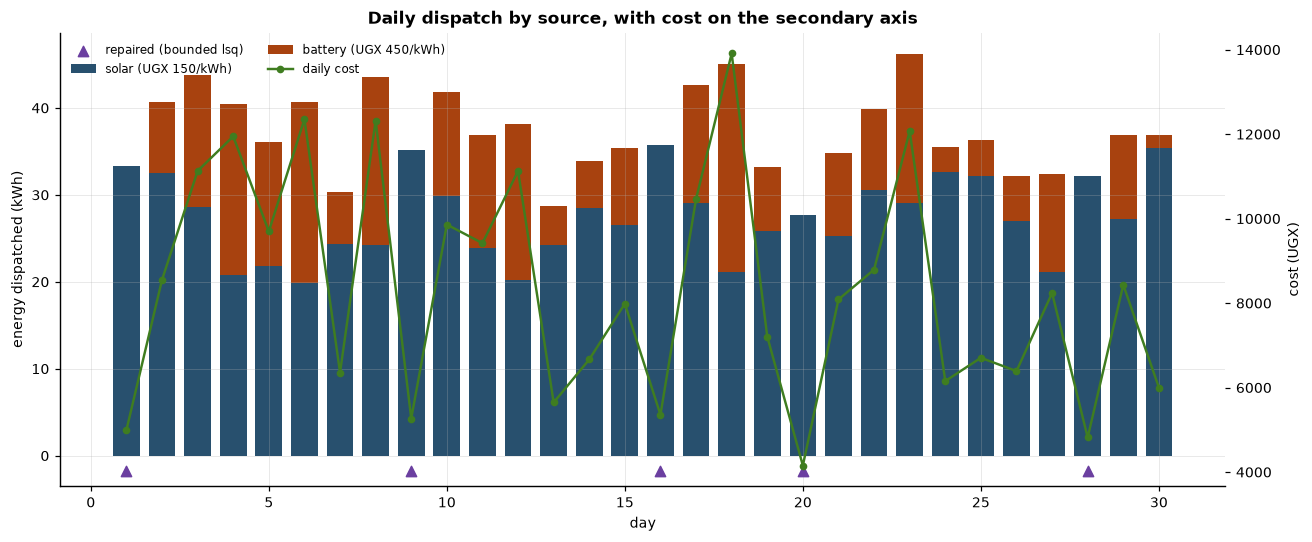

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
days = result.table.index + 1

ax.bar(days, result.table["solar"], label="solar (UGX 150/kWh)",
       color=SERIES_COLOURS[0], width=0.75)
ax.bar(days, result.table["battery"], bottom=result.table["solar"],
       label="battery (UGX 450/kWh)", color=SERIES_COLOURS[1], width=0.75)

repaired_days = result.table.index[result.infeasible] + 1
ax.scatter(repaired_days, np.full(repaired_days.size, -1.8), marker="^", s=45,
           color=SERIES_COLOURS[3], zorder=5, label="repaired (bounded lsq)")

ax.set_xlabel("day")
ax.set_ylabel("energy dispatched (kWh)")
ax.set_ylim(bottom=-3.5)
ax.set_title("Daily dispatch by source, with cost on the secondary axis")

cost_axis = ax.twinx()
cost_axis.plot(days, daily_cost, "o-", color=SERIES_COLOURS[2], lw=1.6,
               label="daily cost")
cost_axis.set_ylabel("cost (UGX)")
cost_axis.grid(False)

bars, bar_labels = ax.get_legend_handles_labels()
lines, line_labels = cost_axis.get_legend_handles_labels()
ax.legend(bars + lines, bar_labels + line_labels, loc="upper left", fontsize=8,
          ncol=2)
fig.tight_layout()
print("saved:", store(fig, "p2_dispatch_and_cost.png").name)
plt.show()

The repaired days are visible as the bars with almost no battery
contribution, and the cost line dips with them. That dip is misleading if
read alone: those days look cheap precisely because demand went unserved.

## Extension 1: diesel, and a third constraint

`HybridMicroGrid` subclasses `MicroGrid` and inherits every solver,
diagnostic and repair path unchanged; all it supplies is a larger matrix. The
third load chosen here is the **vaccine cold chain**, which runs around the
clock:

$$3x + 2y \phantom{{}+ 5z} = D_1 \quad\text{(daytime)}$$
$$4x + \phantom{2}y \phantom{{}+ 5z} = D_2 \quad\text{(critical equipment)}$$
$$\phantom{3}x + 2y + 5z = D_3 \quad\text{(cold chain)}$$

The coefficients say diesel is the efficient way to hold a fridge overnight,
which is the reason a health centre installs one.

In [16]:
hybrid = HybridMicroGrid()
print(repr(hybrid))
hybrid.conditioning().to_frame("value")

HybridMicroGrid(size=3, det=-25, cond=7.011, repair=bounded-lsq)


,value
size,3
determinant,-25.000
condition_number,7.011
rank,3
full_rank,True
well_posed,True


In [17]:
cold_chain = np.round(demands.sum(axis=0) * 0.55, 2)       # illustrative D3
three_load = np.vstack([demands, cold_chain])
hybrid_result = hybrid.dispatch(three_load)
print(repr(hybrid_result))
hybrid_result.table.head(6).round(2)

DispatchResult(days=30, repaired=5, strategy=bounded-lsq, unserved=26.6 kWh)


,solar,battery,diesel,D1,D2,D3,repaired,unserved_kwh
day,,,,,,,,
0,33.300,0.000,18.850,95.300,136.650,127.570,True,5.750
1,32.530,8.160,17.970,113.920,138.290,138.720,False,0.000
2,28.650,15.190,15.260,116.310,129.770,135.340,False,0.000
3,20.780,19.620,10.470,101.600,102.760,112.400,False,0.000
4,21.870,14.260,11.470,94.130,101.740,107.730,False,0.000
5,19.870,20.830,9.870,101.280,100.320,110.880,False,0.000


In [18]:
print("hybrid volatility:")
print(hybrid.volatility(hybrid_result.allocation()).round(3).to_string())
print(f"\n30-day cost with diesel: UGX "
      f"{EnergyTariff().over_period(hybrid_result.table):,.0f}")

hybrid volatility:
         mean_kwh  variance  stdev    cv
source                                  
solar      27.543    22.802  4.775 0.173
battery     9.348    49.092  7.007 0.750
diesel     15.025     9.437  3.072 0.204

30-day cost with diesel: UGX 655,829


### What if the third equation is linearly dependent?

In [19]:
broken = HybridMicroGrid.linearly_dependent()
print("third row replaced by (row 1 + row 2):")
print(broken.A)
print(f"\ndet = {broken.det:.4g}, rank = {broken.rank} of {broken.size}, "
      f"well posed = {broken.well_posed}")
try:
    broken.solve_day(100, 120, 220)
except ValueError as err:
    print("refused ->", err)

third row replaced by (row 1 + row 2):
[[3. 2. 0.]
 [4. 1. 0.]
 [7. 3. 0.]]

det = 0, rank = 2 of 3, well posed = False
refused -> refusing to solve an ill-posed system (det=0, cond=inf)


With $D_3 = D_1 + D_2$ the third equation is already implied by the first
two. It contributes no information, the rank falls to 2 and the determinant
vanishes. The problem does not become hard — it becomes **ill-posed**. If the
measured $D_3$ happens to equal $D_1 + D_2$ exactly there are infinitely many
valid dispatches and nothing to choose between them; if it does not, and with
real meters it never will, there is no dispatch at all. That is why the
determinant is checked *before* solving: a solver handed a singular system
returns either nonsense or a numerical explosion, and neither announces
itself.

## Extension 2: what if the meters are wrong?

Each demand is perturbed by up to ±5%, uniformly, 1,000 times. The question
is how much of that error reaches the dispatch, and whether the condition
number predicted it.

In [20]:
nominal = demands.mean(axis=1)
study = perturbation_study(grid, nominal, spread=0.05, draws=1_000, seed=SEED)
solutions = study["solutions"]

summary = pd.DataFrame({
    "unperturbed": study["base"],
    "mean": solutions.mean(axis=1),
    "sd": solutions.std(axis=1, ddof=1),
    "p2.5": np.percentile(solutions, 2.5, axis=1),
    "p97.5": np.percentile(solutions, 97.5, axis=1),
}, index=list(grid.sources))
summary["relative sd"] = summary["sd"] / summary["unperturbed"]
summary

,unperturbed,mean,sd,p2.5,p97.5,relative sd
solar,27.898,27.932,1.473,25.270,30.650,0.053
battery,8.460,8.406,3.017,2.374,14.294,0.357


In [21]:
print(f"condition number    : {study['cond']:.3f}")
print(f"worst amplification : {study['worst']:.3f}")
print(f"typical (median)    : {study['typical']:.3f}")
assert study["worst"] <= study["cond"] + 1e-9
print("\nThe worst case observed sits just below the condition number, which is")
print("exactly the bound kappa promises. On a 2x2 system the bound is nearly")
print("tight, because random perturbation finds its worst direction quickly.")

condition number    : 5.828
worst amplification : 5.801
typical (median)    : 3.855

The worst case observed sits just below the condition number, which is
exactly the bound kappa promises. On a 2x2 system the bound is nearly
tight, because random perturbation finds its worst direction quickly.


saved: p2_sensitivity.png


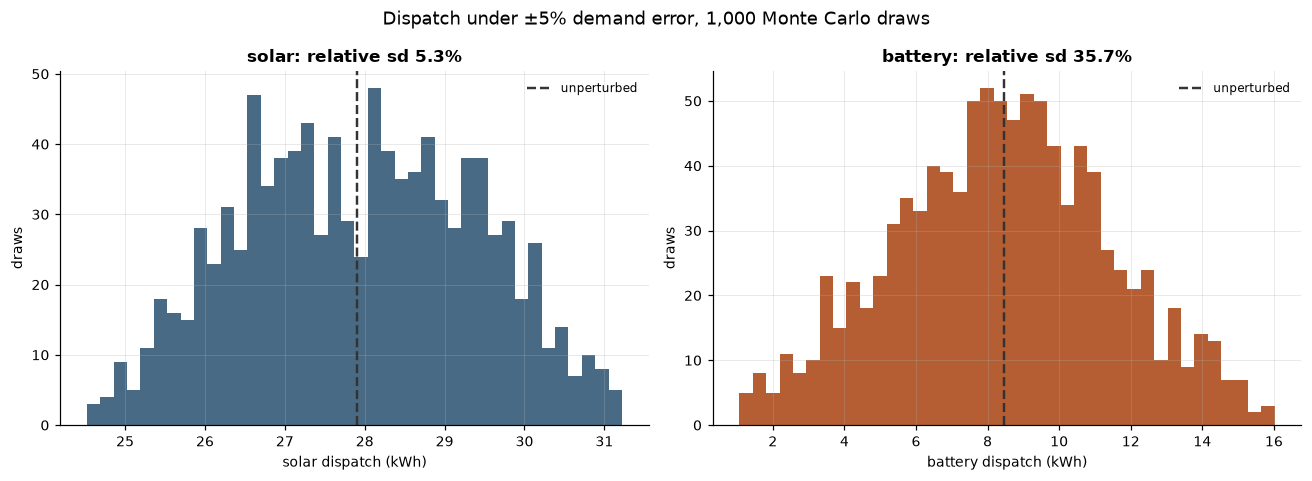

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, index in zip(axes, range(grid.size)):
    name = grid.sources[index]
    ax.hist(solutions[index], bins=40, color=SERIES_COLOURS[index], alpha=0.85)
    ax.axvline(study["base"][index], color="0.2", lw=1.6, ls="--",
               label="unperturbed")
    ax.set_xlabel(f"{name} dispatch (kWh)")
    ax.set_ylabel("draws")
    ax.set_title(f"{name}: relative sd {summary.loc[name, 'relative sd']:.1%}")
    ax.legend(fontsize=8)
fig.suptitle("Dispatch under ±5% demand error, 1,000 Monte Carlo draws", fontsize=12)
fig.tight_layout()
print("saved:", store(fig, "p2_sensitivity.png").name)
plt.show()

The asymmetry is the real result. Solar moves by a few percent; the battery,
which is a small difference between two larger numbers, moves by several
times more in relative terms. The condition number is a property of the
*system*, but the risk it describes lands almost entirely on one component of
the answer — and that only becomes visible by simulating.

## Findings & Limitations

**Findings.** The system is well posed and well conditioned: $\det A = -5$
and $\kappa \approx 5.83$, so a unique dispatch exists for every demand pair
and a 1% metering error cannot grow beyond about 6% in the answer. The Monte
Carlo study confirmed that empirically, with the worst amplification over
1,000 draws landing just under $\kappa$, though the error falls almost
entirely on the battery rather than being shared. Solving all 30 days in one
batched call runs several times faster than looping, almost entirely because
it pays SciPy's per-call overhead once rather than thirty times. Five of the
30 days had no feasible exact solution — all of them days where
$D_2 > \tfrac{4}{3}D_1$ drives the battery negative. Treating the repair as a
pluggable strategy made the choice measurable rather than assumed: clipping
leaves about 60 kWh of demand unserved across the month, while re-solving
under a non-negativity constraint leaves about 27 kWh, **a 55% improvement on
exactly the same days**. The battery is far the more volatile source (CV 0.75
against solar's 0.17) because it absorbs whatever the fixed load ratio leaves
over, and at three times the tariff it takes about half the bill on a quarter
of the energy: roughly UGX 8,300 a day, or UGX 250,000 a month. Adding diesel
under a cold-chain constraint leaves the system well conditioned
($\det = -25$, $\kappa \approx 7.0$).

**Limitations.** The demand data are synthetic, so the count of infeasible
days reflects the generator's noise rather than anything about Kasese; a
different seed gives a different count. The model is a pure equality system
with no capacity limits, so nothing prevents it dispatching more solar at
night than panels could produce, and no storage state carries charge between
days — a real planner needs inequality constraints and an inter-temporal
model rather than 30 independent square solves. The least-squares repair
minimises the Euclidean residual, which implicitly treats a kWh of unserved
daytime load as exactly as costly as a kWh of unserved critical-equipment
load; in a health centre that is plainly false, and a weighted objective
would be more defensible. The tariffs are flat and ignore battery
degradation, which is the dominant real cost of cycling storage hard, so the
true cost of leaning on the battery is understated here. Finally, the
condition number bounds relative error in a norm and says nothing about which
component absorbs it — here the battery takes nearly all of it.